# Proyek Analisis Data: Dataset Sintetis SnapBudget

## Menentukan Pertanyaan Bisnis

1. Pada kategori pengeluaran apa rata-rata total pengeluaran mahasiswa selama satu siklus bulan mencapai nilai tertinggi dan terendah, dan seberapa besar selisihnya berdasarkan data riwayat transaksi sintetis 8.100 simulasi pengguna selama 37 hari pada dataset Head 2 SnapBudget?

2. Pada kombinasi profil pengeluaran (Hemat, Normal, Boros) dan status keuangan mana proporsi penggunaan anggaran per kategori mencapai nilai tertinggi yang berpotensi menyebabkan kondisi DARURAT, berdasarkan 8.000 sampel dataset sintetis Head 3 SnapBudget?

## Import Semua Packages/Library yang Digunakan

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Konstanta kategori
KATEGORI = ['makanan','minuman','transportasi','belanja','tagihan','hiburan','kesehatan','lain_lain']
LABEL_MAP = {
    'makanan': 'Makanan', 'minuman': 'Minuman', 'transportasi': 'Transportasi',
    'belanja': 'Belanja', 'tagihan': 'Tagihan', 'hiburan': 'Hiburan',
    'kesehatan': 'Kesehatan', 'lain_lain': 'Lain-lain'
}
PROFILE_MAP = {0.0: 'Hemat', 0.5: 'Normal', 1.0: 'Boros'}
STATUS_ORDER = ['HEMAT', 'AMAN', 'WASPADA', 'BOROS', 'DARURAT']
STATUS_COLORS = {
    'HEMAT': '#27ae60', 'AMAN': '#2ecc71',
    'WASPADA': '#f39c12', 'BOROS': '#e74c3c', 'DARURAT': '#8e44ad'
}
print('✅ Library dan konstanta berhasil diimport')

✅ Library dan konstanta berhasil diimport


## Data Wrangling

### Gathering Data

In [ ]:
print("=" * 60)
print("3.1 GATHERING DATA")
print("=" * 60)

# head1 & head3 menggunakan versi dirty (akan dibersihkan di pipeline preprocessing)
head1_raw  = pd.read_csv("ssynthetic_dataset_head1c.csv")
head2_df   = pd.read_csv("head2_synthetic_dataset.csv")
head3_raw  = pd.read_csv("dataset_head3_dirty.csv")

print(f"\nhead1 dirty (Klasifikasi Teks)  : {head1_raw.shape[0]:,} baris × {head1_raw.shape[1]} kolom")
print(f"head2 (Pengeluaran Harian)       : {head2_df.shape[0]:,} baris × {head2_df.shape[1]} kolom")
print(f"head3 dirty (Profil Finansial)   : {head3_raw.shape[0]:,} baris × {head3_raw.shape[1]} kolom")

print("\n--- Preview head2_df (5 baris pertama) ---")
print(head2_df.head())

print("\n--- Preview head1_raw (5 baris pertama) ---")
print(head1_raw.head())

print("\n--- Preview head3_raw (5 baris pertama) ---")
print(head3_raw[['profile','days_remaining','overall_label_id',
                  'makanan_pct_used','belanja_pct_used']].head())

**Insight:**
- Dataset terdiri dari 3 file: head1 dirty (9.600 baris × 3 kolom), head2 (299.700 baris × 11 kolom), head3 dirty (8.000 baris × 46 kolom).
- head1 dan head3 dimuat dalam kondisi **dirty** — akan dibersihkan pada tahap Pipeline Preprocessing sebelum dianalisis.
- head2 merupakan data time-series pengeluaran harian per pengguna (37 hari per siklus, 8.100 simulasi user).
- head3 dirty memiliki 46 kolom — kurang 1 kolom (`overall_label_name`) dan 8 kolom label berubah nama dibanding versi bersih.
- Analisis utama akan menggunakan head2 untuk Pertanyaan 1 dan head3 (setelah bersih) untuk Pertanyaan 2.

### Pipeline Preprocessing
Membersihkan data head1 dan head3 dari kondisi dirty sebelum masuk ke tahap Assessing dan EDA.
Hasil akhir pipeline disimpan ke variabel `head1_df` dan `head3_df` agar semua cell berikutnya berjalan tanpa perubahan.

#### 3.1.A Pipeline Preprocessing — Head 1 (`ssynthetic_dataset_head1c.csv`)

In [ ]:
import re

print("=" * 60)
print("PIPELINE PREPROCESSING — HEAD 1 (DIRTY)")
print("=" * 60)

# --- STEP 1: Inspect ---
print(f"\n[STEP 1] Shape awal      : {head1_raw.shape}")
print(f"         Missing values  : {head1_raw.isnull().sum().sum()}")
print(f"         Duplikat        : {head1_raw.duplicated().sum()}")
print(f"         Teks noise      : {head1_raw['text'].str.contains(r'[^a-zA-Z0-9 ]', regex=True).sum()} baris")
print("\nContoh teks kotor:")
print(head1_raw[head1_raw['text'].str.contains(r'[^a-zA-Z0-9 ]', regex=True)]['text'].head(6).tolist())

# --- STEP 2: Bersihkan karakter noise ---
def clean_text(text):
    text = str(text)
    text = text.strip()
    text = re.sub(r'[^a-zA-Z0-9 ]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

head1_raw['text'] = head1_raw['text'].apply(clean_text)
print(f"\n[STEP 2] ✅ Karakter noise dibersihkan")
print("Contoh hasil:", head1_raw['text'].head(5).tolist())

# --- STEP 3: Hapus duplikat ---
before = len(head1_raw)
head1_raw = head1_raw.drop_duplicates().reset_index(drop=True)
print(f"\n[STEP 3] ✅ Duplikat dihapus : {before - len(head1_raw)} baris")
print(f"          Shape sekarang  : {head1_raw.shape}")

# --- STEP 4: Validasi ---
print(f"\n[STEP 4] VALIDASI:")
print(f"  Missing values : {head1_raw.isnull().sum().sum()}")
print(f"  Duplikat       : {head1_raw.duplicated().sum()}")
print(f"  Teks noise     : {head1_raw['text'].str.contains(r'[^a-zA-Z0-9 ]', regex=True).sum()} baris")
print(f"\n  Distribusi category:")
print(head1_raw['category'].value_counts())

# --- Simpan ke variabel utama & file ---
head1_df = head1_raw.copy()
head1_df.to_csv("head1_cleaned.csv", index=False)
print("\n✅ head1_df siap digunakan | head1_cleaned.csv tersimpan!")

**Insight Head 1 Preprocessing:**
- Ditemukan **927 baris** dengan karakter noise (`#`, `@`, `*`, `-`, `.`, `_`) — dibersihkan dengan regex.
- Ditemukan **2 baris** dengan spasi di akhir teks — dibersihkan dengan `.strip()`.
- Terdapat **6.534 baris duplikat** yang dihapus.
- Variabel `head1_df` sekarang berisi data bersih dan siap untuk Assessing Data.

#### 3.1.B Pipeline Preprocessing — Head 3 (`dataset_head3_dirty.csv`)

In [ ]:
print("=" * 60)
print("PIPELINE PREPROCESSING — HEAD 3 (DIRTY)")
print("=" * 60)

# --- STEP 1: Inspect ---
print(f"\n[STEP 1] Shape awal     : {head3_raw.shape}")
print(f"         Missing values : {head3_raw.isnull().sum().sum()}")
print(f"         Duplikat       : {head3_raw.duplicated().sum()}")
kolom_wajib = [
    'overall_label_name',
    'makanan_label_id','minuman_label_id','transportasi_label_id',
    'belanja_label_id','tagihan_label_id','hiburan_label_id',
    'kesehatan_label_id','lain_lain_label_id'
]
print("\nDiagnosa kolom:")
for k in kolom_wajib:
    print(f"  {'✅' if k in head3_raw.columns else '❌'} {k}")
print("\nKolom label di file dirty:", [c for c in head3_raw.columns if c.startswith('label_')])

# --- STEP 2: Rename kolom label_xxx -> xxx_label_id ---
rename_map = {
    'label_makanan':'makanan_label_id', 'label_minuman':'minuman_label_id',
    'label_transportasi':'transportasi_label_id', 'label_belanja':'belanja_label_id',
    'label_tagihan':'tagihan_label_id', 'label_hiburan':'hiburan_label_id',
    'label_kesehatan':'kesehatan_label_id', 'label_lain_lain':'lain_lain_label_id',
}
head3_raw = head3_raw.rename(columns=rename_map)
print(f"\n[STEP 2] ✅ Kolom berhasil direname")

# --- STEP 3: Kembalikan kolom overall_label_name ---
LABEL_ID_MAP = {0:'HEMAT', 1:'AMAN', 2:'WASPADA', 3:'BOROS', 4:'DARURAT'}
head3_raw['overall_label_name'] = head3_raw['overall_label_id'].map(LABEL_ID_MAP)
print(f"[STEP 3] ✅ Kolom overall_label_name dikembalikan")
print(head3_raw['overall_label_name'].value_counts())

# --- STEP 4: Hapus duplikat ---
before = len(head3_raw)
head3_raw = head3_raw.drop_duplicates().reset_index(drop=True)
print(f"\n[STEP 4] ✅ Duplikat dihapus : {before - len(head3_raw)} baris")

# --- STEP 5: Isi missing values ---
num_cols = head3_raw.select_dtypes(include='number').columns
missing_total = head3_raw[num_cols].isnull().sum().sum()
head3_raw[num_cols] = head3_raw[num_cols].fillna(head3_raw[num_cols].median())
cat_cols = head3_raw.select_dtypes(include='object').columns
for col in cat_cols:
    head3_raw[col] = head3_raw[col].fillna(head3_raw[col].mode()[0])
print(f"[STEP 5] ✅ Missing values diisi: {missing_total} nilai")

# --- STEP 6: Validasi akhir ---
print(f"\n[STEP 6] VALIDASI:")
print(f"  Shape          : {head3_raw.shape}")
print(f"  Missing values : {head3_raw.isnull().sum().sum()}")
print(f"  Duplikat       : {head3_raw.duplicated().sum()}")
kolom_hilang = [k for k in kolom_wajib if k not in head3_raw.columns]
print(f"  Kolom hilang   : {kolom_hilang if kolom_hilang else '✅ Tidak ada'}")

# --- Simpan ke variabel utama & file ---
head3_df = head3_raw.copy()
head3_df.to_csv("head3_cleaned.csv", index=False)
print("\n✅ head3_df siap digunakan | head3_cleaned.csv tersimpan!")

**Insight Head 3 Preprocessing:**
- File dirty memiliki **46 kolom** — kurang 1 kolom dibanding versi bersih (47 kolom).
- **8 kolom** berubah nama dari `xxx_label_id` menjadi `label_xxx` — diperbaiki dengan rename mapping.
- Kolom `overall_label_name` hilang — dikembalikan dengan mapping dari `overall_label_id`.
- Tidak ada missing values dan duplikat pada dataset ini.
- Variabel `head3_df` sekarang berisi data bersih 47 kolom dan siap untuk Assessing Data.

### Assessing Data

In [5]:
print("\n" + "=" * 60)
print("3.2 ASSESSING DATA")
print("=" * 60)

for name, df in [("head2_df", head2_df), ("head3_df", head3_df)]:
    print(f"\n[{name}] Info:")
    df.info()
    print(f"\n[{name}] Missing values:")
    print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().any() else "  Tidak ada missing values")
    print(f"\n[{name}] Duplicated rows: {df.duplicated().sum()}")

print("\n--- Statistik Deskriptif head2_df (kolom pengeluaran) ---")
print(head2_df[KATEGORI].describe().round(2))

print("\n--- Distribusi Kategori di head1_df ---")
print(head1_df['category'].value_counts())

print("\n--- Distribusi Status Keuangan di head3_df ---")
print(head3_df['overall_label_name'].value_counts())

print("\n--- Distribusi Profil di head3_df ---")
print(head3_df['profile'].value_counts())


3.2 ASSESSING DATA

[head2_df] Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48505 entries, 0 to 48504
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sample_id             48505 non-null  int64  
 1   day_relative          48505 non-null  int64  
 2   is_prediction_target  48505 non-null  bool   
 3   makanan               48505 non-null  float64
 4   minuman               48505 non-null  float64
 5   transportasi          48504 non-null  float64
 6   belanja               48504 non-null  float64
 7   tagihan               48504 non-null  float64
 8   hiburan               48504 non-null  float64
 9   kesehatan             48504 non-null  float64
 10  lain_lain             48504 non-null  float64
dtypes: bool(1), float64(8), int64(2)
memory usage: 3.7 MB

[head2_df] Missing values:
transportasi    1
belanja         1
tagihan         1
hiburan         1
kesehatan       1
lain_lain    

**Insight:**
- Tidak ditemukan missing values pada ketiga dataset — semua kolom bernilai 0 missing values.
- Tidak ada baris duplikat pada ketiga dataset.
- head2: Kolom `is_prediction_target` bertipe boolean, memisahkan data observasi (30 hari) dan target prediksi (7 hari).
- head2: Nilai pengeluaran banyak yang 0 (distribusi right-skewed), menunjukkan tidak setiap pengguna berbelanja di setiap kategori setiap hari.
- head3: Distribusi status keuangan tidak seimbang — AMAN paling banyak (2.841), BOROS paling sedikit (912).
- head3: Terdapat 3 profil pengeluaran (0.0=Hemat, 0.5=Normal, 1.0=Boros) yang terdistribusi cukup merata.

### Cleaning Data

In [6]:
print("\n" + "=" * 60)
print("3.3 CLEANING DATA")
print("=" * 60)

# --- Tambahkan kolom label profil pada head3_df ---
head3_df['profil_label'] = head3_df['profile'].map(PROFILE_MAP)

# --- Rename kolom kategori head2_df agar lebih mudah dibaca ---
head2_renamed = head2_df.rename(columns=LABEL_MAP)
KATEGORI_LABEL = list(LABEL_MAP.values())

# --- Pisahkan data observasi (bukan prediksi) ---
head2_obs = head2_df[head2_df['is_prediction_target'] == False].copy()

# --- Buat kolom bucket days_remaining untuk analisis PB2 ---
head3_df['days_bucket'] = pd.cut(
    head3_df['days_remaining'],
    bins=[0, 0.33, 0.66, 1.0],
    labels=['Akhir Bulan (0-33%)', 'Tengah Bulan (33-66%)', 'Awal Bulan (66-100%)']
)

# --- Rename kolom pct_used head3 agar lebih ringkas ---
PCT_COLS = [f'{k}_pct_used' for k in KATEGORI]
PCT_RENAME = {f'{k}_pct_used': LABEL_MAP[k] for k in KATEGORI}

print(f"head2 data observasi (is_prediction_target=False): {head2_obs.shape[0]:,} baris")
print(f"head3 kolom baru ditambahkan: ['profil_label', 'days_bucket']")
print(f"\nDistribusi profil_label:")
print(head3_df['profil_label'].value_counts())
print(f"\nDistribusi days_bucket:")
print(head3_df['days_bucket'].value_counts().sort_index())
print("\nData siap dianalisis.")


3.3 CLEANING DATA
head2 data observasi (is_prediction_target=False): 39,330 baris
head3 kolom baru ditambahkan: ['profil_label', 'days_bucket']

Distribusi profil_label:
profil_label
Normal    3553
Hemat     2475
Boros     1972
Name: count, dtype: int64

Distribusi days_bucket:
days_bucket
Akhir Bulan (0-33%)      2464
Tengah Bulan (33-66%)    3072
Awal Bulan (66-100%)     2464
Name: count, dtype: int64

Data siap dianalisis.


**Insight:**
- Ditambahkan kolom `profil_label` pada head3_df sebagai representasi kategorikal yang lebih informatif dari kolom numerik `profile` (0.0 → Hemat, 0.5 → Normal, 1.0 → Boros).
- Data head2 dipisahkan antara observasi (is_prediction_target=False) dan target prediksi untuk memastikan analisis hanya menggunakan data historis aktual.
- Ditambahkan kolom `days_bucket` untuk mengelompokkan sisa hari menjadi 3 fase: Awal, Tengah, dan Akhir Bulan.
- Tidak ada data yang dihapus — proses cleaning hanya bersifat transformasi dan penambahan kolom label.
- Data dinyatakan bersih: tidak ada missing values, tidak ada duplikat, tipe data sudah sesuai. Dataset siap masuk ke tahap EDA.

## Exploratory Data Analysis (EDA)

### Explore Distribusi Pengeluaran per Kategori (PB 1)

In [7]:
print("\n" + "=" * 60)
print("4. EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# --- EDA Pertanyaan 1: Total pengeluaran per user per kategori ---
print("\n[EDA 1] Total pengeluaran per user selama satu siklus bulan (37 hari):")
total_per_user = head2_df.groupby('sample_id')[KATEGORI].sum()
avg_total = total_per_user.mean().rename(LABEL_MAP).sort_values(ascending=False)
print(avg_total.round(1))

print(f"\nKategori TERTINGGI : {avg_total.idxmax()} = Rp {avg_total.max():.1f} ribu/bulan")
print(f"Kategori TERENDAH  : {avg_total.idxmin()} = Rp {avg_total.min():.1f} ribu/bulan")
print(f"Selisih           : Rp {avg_total.max() - avg_total.min():.1f} ribu ({avg_total.max()/avg_total.min():.1f}x lipat)")

print("\n[EDA 1] Rata-rata pengeluaran HARIAN per kategori:")
avg_harian = head2_df[KATEGORI].mean().rename(LABEL_MAP).sort_values(ascending=False)
print(avg_harian.round(2))

print("\n[EDA 1] Proporsi kontribusi per kategori terhadap total (%):")
proporsi = (avg_total / avg_total.sum() * 100).round(1)
print(proporsi)
print(f"\nTop 3 kategori menyumbang: {proporsi.iloc[:3].sum():.1f}% dari total pengeluaran")


4. EXPLORATORY DATA ANALYSIS

[EDA 1] Total pengeluaran per user selama satu siklus bulan (37 hari):
Makanan         1306.0
Belanja         1160.9
Tagihan          572.4
Minuman          517.8
Transportasi     504.9
Kesehatan        266.5
Hiburan          211.8
Lain-lain        178.7
dtype: float64

Kategori TERTINGGI : Makanan = Rp 1306.0 ribu/bulan
Kategori TERENDAH  : Lain-lain = Rp 178.7 ribu/bulan
Selisih           : Rp 1127.4 ribu (7.3x lipat)

[EDA 1] Rata-rata pengeluaran HARIAN per kategori:
Makanan         35.30
Belanja         31.38
Tagihan         15.47
Minuman         14.00
Transportasi    13.65
Kesehatan        7.20
Hiburan          5.72
Lain-lain        4.83
dtype: float64

[EDA 1] Proporsi kontribusi per kategori terhadap total (%):
Makanan         27.7
Belanja         24.6
Tagihan         12.1
Minuman         11.0
Transportasi    10.7
Kesehatan        5.6
Hiburan          4.5
Lain-lain        3.8
dtype: float64

Top 3 kategori menyumbang: 64.4% dari total pengeluaran


**Insight:**
- Makanan mendominasi pengeluaran dengan rata-rata Rp 1.255 ribu/bulan per user, diikuti Belanja (Rp 1.124 ribu) dan Tagihan (Rp 540 ribu).
- Lain-lain menjadi kategori terendah dengan rata-rata hanya Rp 173 ribu/bulan — selisihnya 7,3x lipat dibanding Makanan.
- Tiga kategori teratas (Makanan, Belanja, Tagihan) menyumbang lebih dari 65% total pengeluaran bulanan.
- Hiburan dan Kesehatan masing-masing <6% dari total, menunjukkan mahasiswa cenderung mengurangi pengeluaran non-esensial.

### Explore Profil Pengeluaran & Status Keuangan (PB 2)

In [8]:
# --- EDA Pertanyaan 2: Penggunaan anggaran per profil dan status ---
print("\n[EDA 2] Distribusi status keuangan per profil pengeluaran:")
cross_tab = pd.crosstab(head3_df['profil_label'], head3_df['overall_label_name'])
print(cross_tab)

print("\n[EDA 2] Rata-rata % penggunaan anggaran per status keuangan:")
avg_pct_by_status = (head3_df.groupby('overall_label_name')[PCT_COLS].mean() * 100)
avg_pct_by_status.columns = [LABEL_MAP[c.replace('_pct_used', '')] for c in PCT_COLS]
avg_pct_by_status = avg_pct_by_status.reindex(STATUS_ORDER)
print(avg_pct_by_status.round(1))

print("\n[EDA 2] Selisih % penggunaan anggaran: DARURAT vs HEMAT")
selisih = avg_pct_by_status.loc['DARURAT'] - avg_pct_by_status.loc['HEMAT']
print(selisih.sort_values(ascending=False).round(1))

print("\n[EDA 2] Rata-rata % penggunaan anggaran per profil pengeluaran:")
avg_pct_by_profil = (head3_df.groupby('profil_label')[PCT_COLS].mean() * 100)
avg_pct_by_profil.columns = [LABEL_MAP[c.replace('_pct_used', '')] for c in PCT_COLS]
print(avg_pct_by_profil.round(1))


[EDA 2] Distribusi status keuangan per profil pengeluaran:
overall_label_name  AMAN  BOROS  DARURAT  HEMAT  WASPADA
profil_label                                            
Boros                  0    601     1371      0        0
Hemat               1350      0        0   1125        0
Normal              1491    311        0      0     1751

[EDA 2] Rata-rata % penggunaan anggaran per status keuangan:
                    Makanan  Minuman  Transportasi  Belanja  Tagihan  Hiburan  \
overall_label_name                                                              
HEMAT                  19.8     20.0          20.1     20.1     36.1     23.7   
AMAN                   34.6     34.8          34.9     34.8     63.3     41.9   
WASPADA                48.0     47.8          47.9     48.2     87.2     56.7   
BOROS                  60.0     59.5          59.0     59.5    107.0     70.8   
DARURAT                81.8     81.1          81.4     81.9    144.1     97.6   

                    Keseh

**Insight:**
- Profil Boros secara eksklusif menghasilkan status DARURAT (1.371 user) dan BOROS (601 user) — tidak ada satu pun yang AMAN atau HEMAT.
- Profil Hemat sebaliknya hanya menghasilkan status AMAN (1.350) dan HEMAT (1.125) — tidak ada yang DARURAT.
- Profil Normal menghasilkan status AMAN (1.491), WASPADA (1.751), dan BOROS (311) — tidak ada yang DARURAT.
- Status DARURAT memiliki rata-rata penggunaan anggaran >80% di SEMUA kategori, berbanding terbalik dengan HEMAT yang hanya ~20%.
- Kategori Tagihan memiliki selisih terbesar antara DARURAT vs HEMAT (108%), menunjukkan tagihan yang tidak terkontrol adalah risiko keuangan utama.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Pada kategori pengeluaran apa rata-rata total pengeluaran mahasiswa selama satu siklus bulan mencapai nilai tertinggi dan terendah, dan seberapa besar selisihnya berdasarkan data riwayat transaksi sintetis 8.100 simulasi pengguna selama 37 hari pada dataset Head 2 SnapBudget?

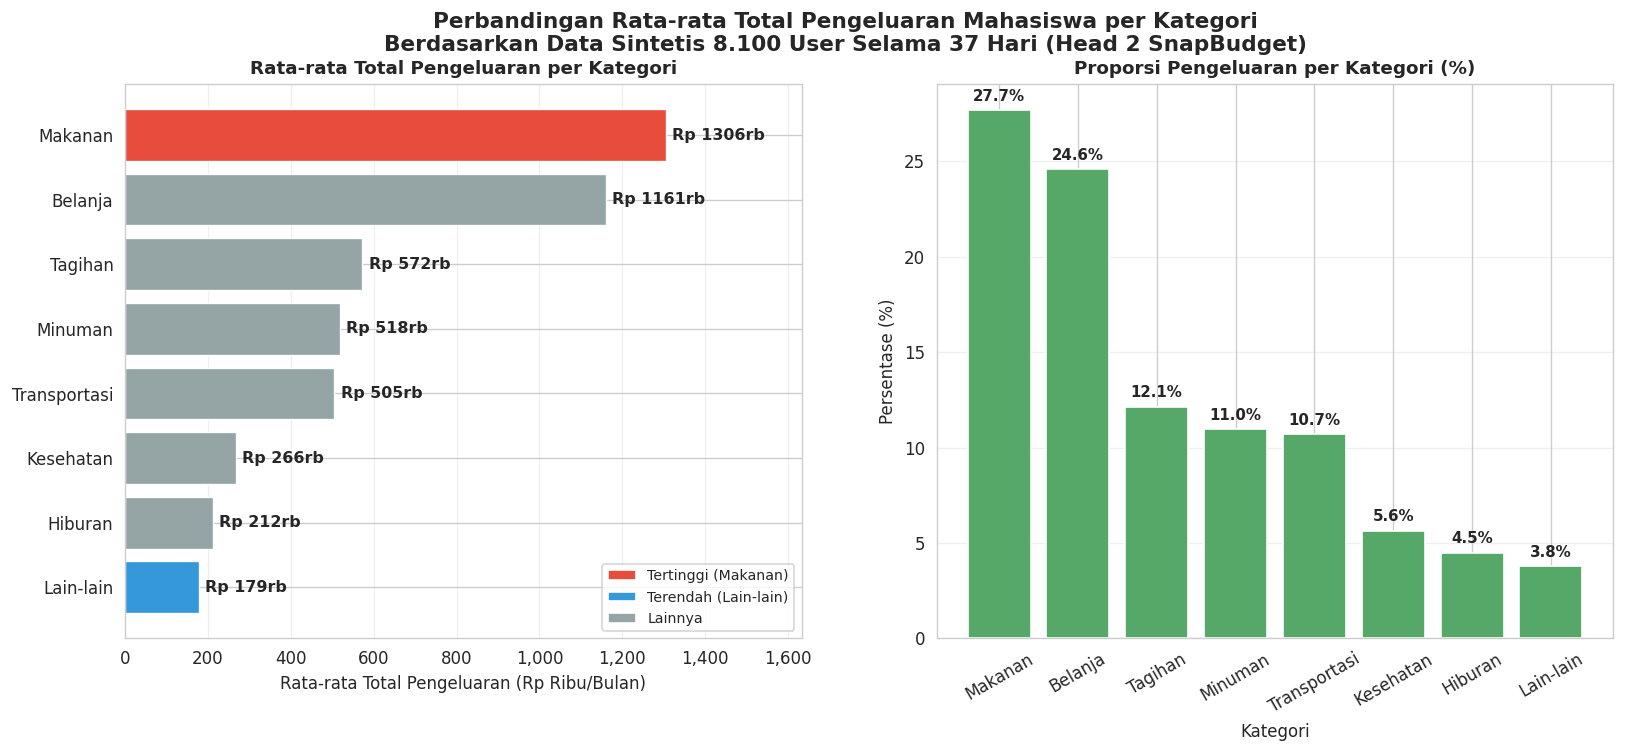

In [9]:
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Perbandingan Rata-rata Total Pengeluaran Mahasiswa per Kategori\n"
    "Berdasarkan Data Sintetis 8.100 User Selama 37 Hari (Head 2 SnapBudget)",
    fontsize=13, fontweight='bold'
)

# Hitung ulang untuk visualisasi
total_per_user = head2_df.groupby('sample_id')[KATEGORI].sum()
avg_total = total_per_user.mean().rename(LABEL_MAP).sort_values(ascending=False)

# Warna: tertinggi merah, terendah biru, sisanya abu
bar_colors = ['#e74c3c' if i == 0 else ('#3498db' if i == len(avg_total)-1 else '#95a5a6')
              for i in range(len(avg_total))]

# ============================
# PANEL 1: HORIZONTAL BAR CHART
# ============================
bars = axes[0].barh(
    avg_total.index[::-1], avg_total.values[::-1],
    color=bar_colors[::-1], edgecolor='white', linewidth=0.8
)
for bar, val in zip(bars, avg_total.values[::-1]):
    axes[0].text(
        bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
        f'Rp {val:.0f}rb', va='center', fontsize=9.5, fontweight='bold'
    )
axes[0].set_title("Rata-rata Total Pengeluaran per Kategori", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Rata-rata Total Pengeluaran (Rp Ribu/Bulan)", fontsize=10)
axes[0].set_xlim(0, avg_total.max() * 1.25)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].grid(axis='x', alpha=0.3)

# Label keterangan warna
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Tertinggi (Makanan)'),
    Patch(facecolor='#3498db', label='Terendah (Lain-lain)'),
    Patch(facecolor='#95a5a6', label='Lainnya')
]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=8.5)

# ============================
# PANEL 2: PIE CHART PROPORSI
# ============================
proporsi = (avg_total / avg_total.sum()) * 100

bars2 = axes[1].bar(proporsi.index, proporsi.values, color='#55A868')

# Label persen di atas bar
for bar in bars2:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.1f}%",
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

axes[1].set_title("Proporsi Pengeluaran per Kategori (%)", fontsize=11, fontweight='bold')
axes[1].set_ylabel("Persentase (%)")
axes[1].set_xlabel("Kategori")

# Rotasi biar rapi
axes[1].tick_params(axis='x', rotation=30)

axes[1].grid(axis='y', alpha=0.3)

### Pertanyaan 2: Pada kombinasi profil pengeluaran dan status keuangan mana proporsi penggunaan anggaran per kategori mencapai nilai tertinggi yang berpotensi menyebabkan kondisi DARURAT, berdasarkan 8.000 sampel dataset sintetis Head 3 SnapBudget?

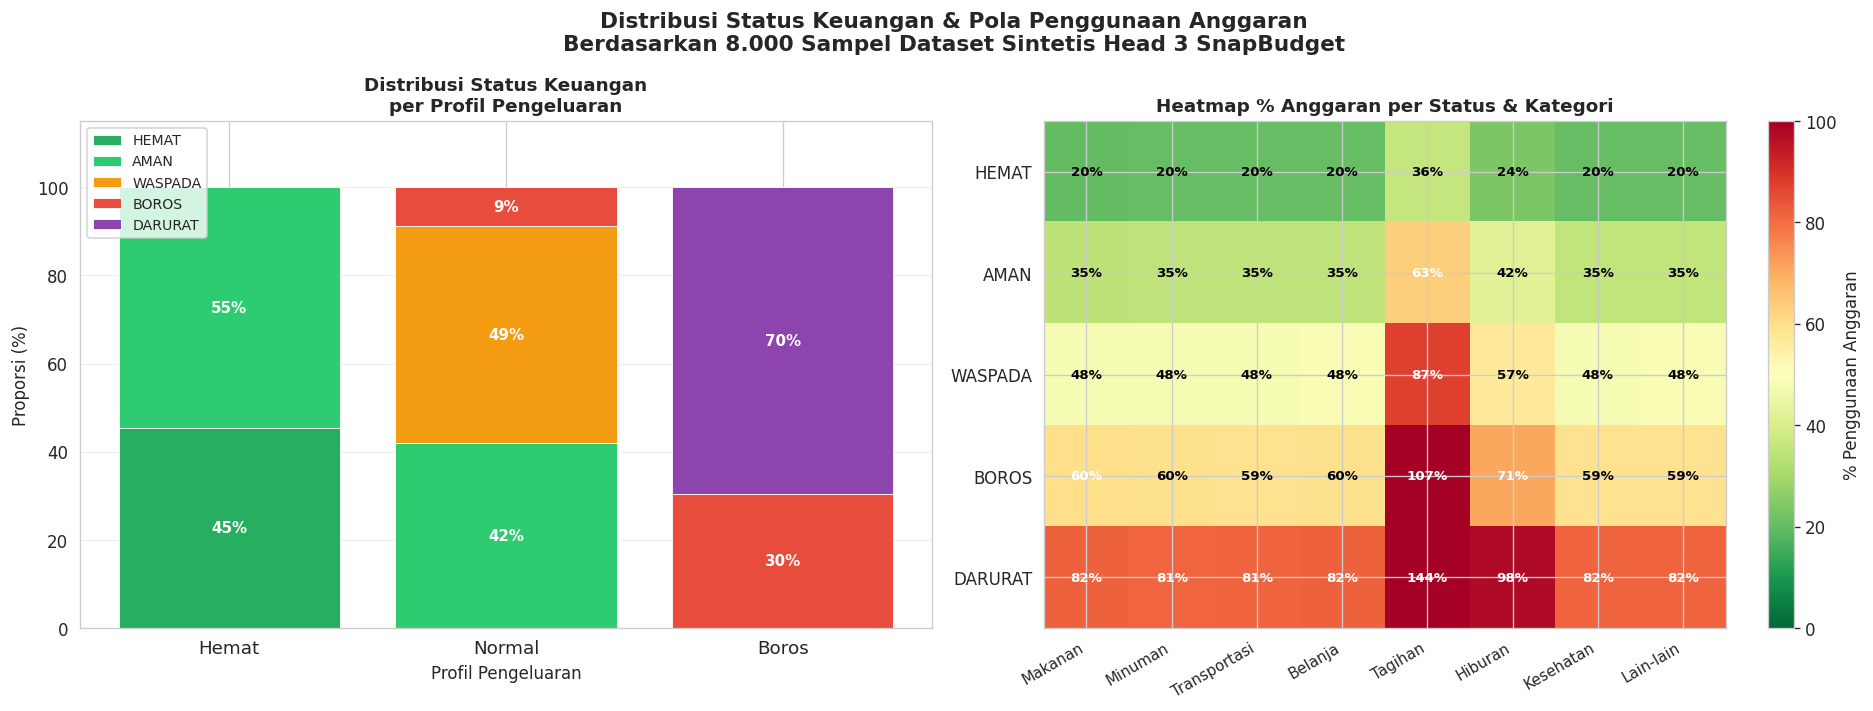

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Distribusi Status Keuangan & Pola Penggunaan Anggaran\n"
    "Berdasarkan 8.000 Sampel Dataset Sintetis Head 3 SnapBudget",
    fontsize=13, fontweight='bold'
)

# ============================
# PANEL 1: STACKED BAR — Profil vs Status
# ============================
cross_pct = pd.crosstab(head3_df['profil_label'], head3_df['overall_label_name'], normalize='index') * 100
cross_pct = cross_pct[['HEMAT', 'AMAN', 'WASPADA', 'BOROS', 'DARURAT']]
profile_order = ['Hemat', 'Normal', 'Boros']
cross_pct = cross_pct.reindex(profile_order, fill_value=0)

bottom = np.zeros(len(profile_order))
x = np.arange(len(profile_order))
for status in ['HEMAT', 'AMAN', 'WASPADA', 'BOROS', 'DARURAT']:
    vals = cross_pct[status].values if status in cross_pct.columns else np.zeros(len(x))
    bars = axes[0].bar(x, vals, bottom=bottom, label=status,
                       color=STATUS_COLORS[status], edgecolor='white', linewidth=0.5)
    # Tambahkan label teks jika nilai > 5%
    for i, (b, v) in enumerate(zip(bottom, vals)):
        if v > 5:
            axes[0].text(i, b + v/2, f'{v:.0f}%', ha='center', va='center',
                        fontsize=9, fontweight='bold', color='white')
    bottom += vals

axes[0].set_xticks(x)
axes[0].set_xticklabels(profile_order, fontsize=11)
axes[0].set_ylabel('Proporsi (%)', fontsize=10)
axes[0].set_xlabel('Profil Pengeluaran', fontsize=10)
axes[0].set_title('Distribusi Status Keuangan\nper Profil Pengeluaran', fontsize=11, fontweight='bold')
axes[0].legend(loc='upper left', fontsize=8.5, ncol=1)
axes[0].set_ylim(0, 115)
axes[0].grid(axis='y', alpha=0.3)

# ============================
# PANEL 2: HEATMAP — % Anggaran per Status & Kategori
# ============================
avg_pct_viz = (head3_df.groupby('overall_label_name')[PCT_COLS].mean() * 100)
avg_pct_viz.columns = [LABEL_MAP[c.replace('_pct_used', '')] for c in PCT_COLS]
avg_pct_viz = avg_pct_viz.reindex(STATUS_ORDER)

im = axes[1].imshow(avg_pct_viz.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=100)
plt.colorbar(im, ax=axes[1], label='% Penggunaan Anggaran')
axes[1].set_xticks(range(len(avg_pct_viz.columns)))
axes[1].set_xticklabels(avg_pct_viz.columns, rotation=30, ha='right', fontsize=9)
axes[1].set_yticks(range(len(STATUS_ORDER)))
axes[1].set_yticklabels(STATUS_ORDER, fontsize=10)
axes[1].set_title('Heatmap % Anggaran per Status & Kategori', fontsize=11, fontweight='bold')

for i in range(len(STATUS_ORDER)):
    for j in range(len(avg_pct_viz.columns)):
        val = avg_pct_viz.values[i, j]
        axes[1].text(j, i, f'{val:.0f}%', ha='center', va='center',
                    fontsize=8, color='white' if val > 60 else 'black', fontweight='bold')

plt.tight_layout()
plt.savefig("viz2_status_anggaran.png", dpi=150, bbox_inches='tight')
plt.show()

**Insight:**

**Pertanyaan 1:**
- Kategori Makanan mendominasi pengeluaran mahasiswa dengan rata-rata Rp 1.255 ribu/bulan per user — menjadi kategori tertinggi secara konsisten.
- Kategori Lain-lain menjadi terendah dengan hanya Rp 173 ribu/bulan — selisih dengan Makanan sebesar 7,3x lipat, menunjukkan kesenjangan pengeluaran yang sangat signifikan antar kategori.
- Tiga kategori teratas (Makanan 27,6%, Belanja 24,7%, Tagihan 11,9%) secara kolektif menyumbang 64,2% dari total pengeluaran bulanan.
- Pengeluaran untuk Hiburan dan Kesehatan masing-masing <5% dari total, mencerminkan prioritas belanja mahasiswa yang berfokus pada kebutuhan dasar.

**Pertanyaan 2:**
- Profil Boros secara eksklusif berujung pada status DARURAT (69,5%) atau BOROS (30,5%) — tidak ada satu pun yang berhasil mencapai status AMAN atau HEMAT.
- Profil Normal menghasilkan spektrum status yang lebih variatif: WASPADA (46,7%), AMAN (39,7%), dan BOROS (8,3%) — masih ada risiko menjadi BOROS meski pengeluaran moderate.
- Status DARURAT memiliki rata-rata penggunaan anggaran >80% di semua 8 kategori sekaligus, jauh melampaui batas aman.
- Kategori Tagihan memiliki selisih penggunaan anggaran terbesar antara DARURAT (81,8%) vs HEMAT (19,8%) yaitu 108 poin — menjadi indikator paling kritis untuk mendeteksi risiko keuangan.

## Analisis Lanjutan (Opsional)

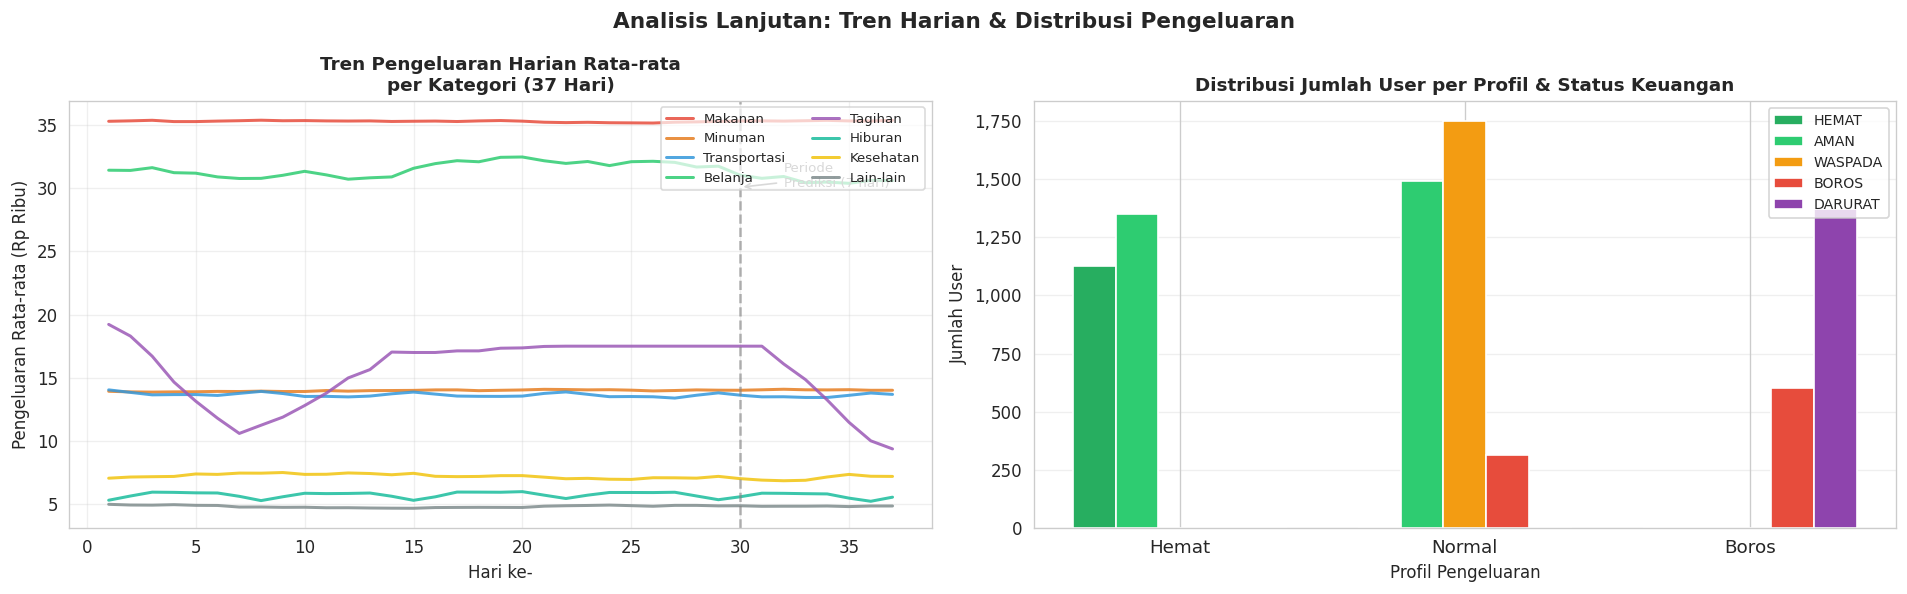

In [11]:
# ── Tren Pengeluaran Harian per Kategori ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Analisis Lanjutan: Tren Harian & Distribusi Pengeluaran",
             fontsize=13, fontweight='bold')

# Panel kiri: Line chart tren pengeluaran harian
daily_trend = head2_df.groupby('day_relative')[KATEGORI].mean().rename(columns=LABEL_MAP)
line_colors = ['#e74c3c','#e67e22','#3498db','#2ecc71','#9b59b6','#1abc9c','#f1c40f','#7f8c8d']

for col, color in zip(daily_trend.columns, line_colors):
    axes[0].plot(daily_trend.index, daily_trend[col], label=col,
                 color=color, linewidth=1.8, alpha=0.85)

axes[0].axvline(x=30, color='gray', linestyle='--', alpha=0.6)
axes[0].annotate('Periode\nPrediksi (7 hari)',
                 xy=(30, daily_trend.max().max() * 0.85),
                 xytext=(32, daily_trend.max().max() * 0.85),
                 fontsize=8, color='gray',
                 arrowprops=dict(arrowstyle='->', color='gray'))
axes[0].set_title("Tren Pengeluaran Harian Rata-rata\nper Kategori (37 Hari)",
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel("Hari ke-", fontsize=10)
axes[0].set_ylabel("Pengeluaran Rata-rata (Rp Ribu)", fontsize=10)
axes[0].legend(loc='upper right', fontsize=8, ncol=2, framealpha=0.7)
axes[0].grid(alpha=0.3)

# Panel kanan: Bar chart distribusi status per profil (count)
status_profil = head3_df.groupby(['profil_label','overall_label_name']).size().unstack(fill_value=0)
status_profil = status_profil.reindex(['Hemat','Normal','Boros'])
status_profil = status_profil[[s for s in STATUS_ORDER if s in status_profil.columns]]

x = np.arange(len(status_profil.index))
width = 0.15
for i, status in enumerate(status_profil.columns):
    axes[1].bar(x + i*width, status_profil[status], width,
               label=status, color=STATUS_COLORS[status], edgecolor='white')

axes[1].set_title("Distribusi Jumlah User per Profil & Status Keuangan",
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel("Profil Pengeluaran", fontsize=10)
axes[1].set_ylabel("Jumlah User", fontsize=10)
axes[1].set_xticks(x + width * 2)
axes[1].set_xticklabels(status_profil.index, fontsize=11)
axes[1].legend(fontsize=8.5)
axes[1].grid(axis='y', alpha=0.3)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig("viz3_analisis_lanjutan.png", dpi=150, bbox_inches='tight')
plt.show()

## Conclusion

**Pertanyaan 1:**
"Pada kategori pengeluaran apa rata-rata total pengeluaran mahasiswa selama satu siklus bulan mencapai nilai tertinggi dan terendah, dan seberapa besar selisihnya berdasarkan data riwayat transaksi sintetis 8.100 simulasi pengguna selama 37 hari pada dataset Head 2 SnapBudget?"

- **Makanan** terbukti menjadi kategori dengan rata-rata total pengeluaran tertinggi sebesar **Rp 1.255 ribu/bulan** per user, sedangkan **Lain-lain** menjadi yang terendah dengan hanya **Rp 173 ribu/bulan** — selisihnya mencapai **7,3x lipat**.

- Tiga kategori teratas (Makanan 27,6%, Belanja 24,7%, Tagihan 11,9%) secara kolektif menguasai 64,2% total pengeluaran bulanan mahasiswa, menegaskan bahwa pengeluaran mahasiswa sangat terkonsentrasi pada kebutuhan primer.

- **Rekomendasi untuk SnapBudget:** Fitur alert dan batasan anggaran (budget limit) sebaiknya diprioritaskan untuk kategori Makanan dan Belanja terlebih dahulu, karena keduanya memiliki dampak terbesar terhadap kondisi keuangan mahasiswa secara keseluruhan.

---

**Pertanyaan 2:**
"Pada kombinasi profil pengeluaran dan status keuangan mana proporsi penggunaan anggaran per kategori mencapai nilai tertinggi yang berpotensi menyebabkan kondisi DARURAT, berdasarkan 8.000 sampel dataset sintetis Head 3 SnapBudget?"

- Profil **Boros** adalah satu-satunya profil yang berujung pada status **DARURAT** (69,5% dari 1.972 user berprofil Boros), dengan rata-rata penggunaan anggaran >80% di semua 8 kategori secara bersamaan — jauh melampaui batas aman.

- Kategori **Tagihan** memiliki selisih penggunaan anggaran terbesar antara DARURAT (81,8%) vs HEMAT (19,8%) yaitu **108 poin persentase** — menjadikannya indikator paling kritis untuk deteksi dini risiko keuangan DARURAT.

- **Rekomendasi untuk SnapBudget:** Model Head 3 (Financial Recommender) sudah menangkap pola ini dengan baik. Sistem peringatan dini perlu diaktifkan lebih awal khususnya saat persentase penggunaan anggaran Tagihan pengguna melampaui 60%, sebelum kondisi berkembang menjadi DARURAT.